# Titanic

In [1]:
# Library descriptions
import pandas as pd # Pandas is a powerful library for data manipulation and analysis 
# (Used for reading, cleaning, transforming, and summarizing datasets)
import numpy as np # NumPy provides support for numerical operations and arrays
# (Often used for handling missing data, mathematical calculations, and data transformations)
import matplotlib.pyplot as plt # Matplotlib is a basic and flexible plotting library
# (Used for creating static, interactive, and animated visualizations)
import seaborn as sns # Seaborn is built on top of Matplotlib and integrates with Pandas
# (It provides easier syntax for statistical plots like boxplots, heatmaps, and barplots)
import scipy.stats as stats # library module that provides a wide range of statistical functions, including probability distributions, hypothesis testing, correlation analysis, and descriptive statistics.
import feature_engine.transformation as vt
from yellowbrick.regressor import ResidualsPlot # Yellowbrick is a visualization library built on top of Scikit-learn and Matplotlib, designed specifically for evaluating machine learning models
# (ResidualsPlot is a visualizer that plots the residuals of a regression model — the difference between actual and predicted values)
from sklearn.model_selection import GridSearchCV, train_test_split  
# GridSearchCV is used for hyperparameter tuning.
# train_test_split splits the dataset into training and testing sets.
from sklearn.pipeline import Pipeline  
# Pipeline chains multiple processing steps into one object (e.g., preprocessing + model).
from sklearn.compose import ColumnTransformer  
# Allows applying different preprocessing pipelines to different columns.
from sklearn.experimental import enable_iterative_imputer  
# Enables access to the experimental IterativeImputer.
from sklearn.impute import IterativeImputer, KNNImputer  
# IterativeImputer models each feature with missing values as a function of other features.
# KNNImputer fills missing values using the k-nearest neighbors algorithm.
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler  
# RobustScaler: scales data using statistics robust to outliers (median/IQR).
# StandardScaler: standardizes features by removing the mean and scaling to unit variance.
# MinMaxScaler: scales features to a specified range (usually 0 to 1).
from sklearn.linear_model import LogisticRegression, LinearRegression  
# LogisticRegression: used for binary classification.
# LinearRegression: used for predicting continuous variables.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor, GradientBoostingClassifier  
# Ensemble models based on decision trees.
# RandomForest: averages multiple deep decision trees to reduce overfitting.
# ExtraTrees: similar to RandomForest, but more randomized.
# GradientBoosting: builds models sequentially to correct the previous ones.
from sklearn.tree import DecisionTreeClassifier  
# A simple tree-based classification algorithm.
from sklearn.svm import SVC  
# Support Vector Classifier: effective for high-dimensional spaces.
from sklearn.neighbors import KNeighborsClassifier  
# KNN: classifies a sample based on the majority class among its k-nearest neighbors.
from sklearn.preprocessing import KBinsDiscretizer  
# Discretizes continuous features into k bins, using strategies like uniform, quantile, or k-means.
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, mean_squared_error, roc_curve, confusion_matrix, f1_score  
# Set of functions for evaluating classification and regression models.
from feature_engine.imputation import CategoricalImputer, RandomSampleImputer, MeanMedianImputer  
# CategoricalImputer: replaces missing values in categorical variables.
# RandomSampleImputer: fills in missing values with random draws from the variable’s distribution.
# MeanMedianImputer: imputes missing values with the mean or median.
from feature_engine.encoding import OneHotEncoder, OrdinalEncoder, CountFrequencyEncoder  
# Encoders for transforming categorical features into numerical representations.
from feature_engine.discretisation import EqualFrequencyDiscretiser  
# Splits continuous data into intervals that contain approximately the same number of observations.
from feature_engine.wrappers import SklearnTransformerWrapper  
# Wraps scikit-learn transformers for use within the feature-engine pipeline.
from feature_engine.discretisation import EqualWidthDiscretiser, DecisionTreeDiscretiser, EqualFrequencyDiscretiser  
# EqualWidth: splits data into equal-width bins.
# DecisionTreeDiscretiser: uses tree algorithm to find optimal splits based on target.
# EqualFrequency: (duplicate import) ensures consistency if used across multiple configs.
from feature_engine.pipeline import Pipeline as FEPipeline  
# Feature-engine's own pipeline, fully compatible with its transformers.

In [2]:
# Functions

# Encoder One-hot encoding(fit, transform)
def get_OHE(df, drop_param=True):
    one_enc = OneHotEncoder(
        top_categories=None,
        variables=['sex','embarked'],
        drop_last=drop_param)

    one_enc.fit(X_train)
    X_df_OHE = one_enc.transform(df)
    return X_df_OHE
    
# Encoder ordinal encoding(fit, transform)
def get_ordinal(df): 
    ord_enc= OrdinalEncoder(
        encoding_method='arbitrary')

    ord_enc.fit(X_train)
    X_df_Ord = ord_enc.transform(df)
    return X_df_Ord

# Count encoding(fit, transform)
def get_count(df): 
    count_enc = CountFrequencyEncoder(
        encoding_method='count')

    count_enc.fit(X_train)
    X_df_Count = count_enc.transform(df)
    return X_df_Count

# fit Logistic regresssion model
def run_logistic(X_train,X_test, y_train, y_test):
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    logit = LogisticRegression(random_state=0, C=0.01, max_iter=100)

    logit.fit(X_train_scaled, y_train)

    print("Train set")
    pred = logit.predict_proba(X_train_scaled)
    print("Logistic regression roc_auc: {}".format(roc_auc_score(y_train, pred[:, 1])))

    print()
    print("Test set")
    pred = logit.predict_proba(X_test_scaled)
    print("Logistic regression roc_auc: {}".format(roc_auc_score(y_test, pred[:, 1])))

# fit RandomForests model
def run_randomForests(X_train, X_test, y_train,y_test):
    rf = RandomForestClassifier(n_estimators=50,random_state=39, max_depth=3)
    rf.fit(X_train, y_train)

    print("Train set")
    pred = rf.predict_proba(X_train)
    print("Random forests roc_auc: {}".format(roc_auc_score(y_train, pred[:, 1])))

    print()
    print("Test set")
    pred = rf.predict_proba(X_test)
    print("Random forests roc_auc: {}".format(roc_auc_score(y_test, pred[:, 1])))

# Distribution plot
def diagnostic_plots(df, variable):
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    df[variable].hist(bins=30)
    plt.title(variable)

    plt.subplot(1,2,2)
    stats.probplot(df[variable], dist='norm', plot=plt)
    plt.title(variable)
    plt.show()
# Confusion matrix
def plot_custom_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('False')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Calculation of metrics and appending to the list
def metrics_gridsearch(model_name, y_test, y_train, y_pred_test,y_proba_test,y_pred_train, y_proba_train, results_df):

    f1_test = round(f1_score(y_test, y_pred_test), 4)
    acc_test = round(accuracy_score(y_test, y_pred_test), 4)
    roc_test = round(roc_auc_score(y_test, y_proba_test), 4)

    f1_train = round(f1_score(y_train, y_pred_train), 4)
    acc_train = round(accuracy_score(y_train, y_pred_train), 4)
    roc_train = round(roc_auc_score(y_train, y_proba_train), 4)
    results_df[model_name + '_test'] = [f1_test, acc_test, roc_test]
    results_df[model_name + '_train'] = [f1_train, acc_train, roc_train]
    return results_df

# Final Summary
def plot_overfit_with_exact_labels(results_df, metric_name):
    df = results_df.T

    df_metric = df[[metric_name]].copy()
    df_metric['model'] = df_metric.index
    df_metric['type'] = df_metric['model'].apply(lambda x: 'train' if 'train' in x else 'test')
    df_metric['model_clean'] = df_metric['model'].apply(lambda x: x.replace('_train', '').replace('_test', ''))

    pivot = df_metric.pivot(index='model_clean', columns='type', values=metric_name).fillna(0)
    pivot['overfit_%'] = ((pivot['train'] - pivot['test']) / pivot['train']) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    train_bars = ax.barh(pivot.index, pivot['train'], color='orange', label='Train')
    test_bars = ax.barh(pivot.index, pivot['test'], color='steelblue', label='Test')
    for i, model in enumerate(pivot.index):
        train_val = pivot.loc[model, 'train']
        test_val = pivot.loc[model, 'test']
        diff = pivot.loc[model, 'overfit_%']
        ax.text(train_val - 0.01, i - 0.15, f'{train_val*100:.1f}%', color='purple', ha='right', fontsize=12)
        ax.text(test_val - 0.01, i + 0.05, f'{test_val*100:.1f}%', color='blue', ha='right', fontsize=12)
        ax.text(max(train_val, test_val) + 0.02, i, f'{diff:.1f}%', color='darkred', ha='left', va='bottom', fontsize=12)

    ax.set_xlabel(metric_name)
    ax.set_title(f'{metric_name}: Train vs Test with % difference')
    ax.set_xlim(0, 1.1)
    ax.legend()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [3]:
# Data read and view
data = pd.read_csv("titanic.csv")
data.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [4]:
engindata = data.drop(['body','boat','cabin','home.dest','ticket', 'name'], axis=1).copy()
engindata

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...,...
1304,3,0,female,14.5000,1,0,14.4542,C
1305,3,0,female,NaN,1,0,14.4542,C
1306,3,0,male,26.5000,0,0,7.2250,C
1307,3,0,male,27.0000,0,0,7.2250,C


In [5]:
# Let's create family
engindata['family'] = engindata.parch + engindata.sibsp
engindata['alone'] = engindata.family == 0
engindata = engindata.replace({True: 1, False: 0})
engindata = engindata.drop(['family','sibsp','parch'], axis=1)

C:\Users\Сен Гван\AppData\Local\Temp\ipykernel_10340\1520090946.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  engindata = engindata.replace({True: 1, False: 0})


In [6]:
engindata.dtypes

pclass        int64
survived      int64
sex          object
age         float64
fare        float64
embarked     object
alone         int64
dtype: object

In [7]:
engindata.isnull().mean()

pclass      0.000000
survived    0.000000
sex         0.000000
age         0.200917
fare        0.000764
embarked    0.001528
alone       0.000000
dtype: float64

In [8]:
imputer = RandomSampleImputer(random_state=0, variables=['embarked','fare'])
engindata = imputer.fit_transform(engindata)

In [9]:
features_categorical = [c for c in engindata.columns if engindata[c].dtypes == 'O']
features_categorical

['sex', 'embarked']

In [10]:
features_numerical = [c for c in engindata.columns if engindata[c].dtypes !='O' and c!='survived']
features_numerical

['pclass', 'age', 'fare', 'alone']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [12]:
num_impute_df = pd.concat([
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
], axis = 1)

num_impute_df.columns = ['age', 'age_median','age_random', 'age_knn', 'age_missforest']
num_impute_df.head()

,age,age_median,age_random,age_knn,age_missforest
501,13.0,13.0,13.0,13.0,13.0
588,4.0,4.0,4.0,4.0,4.0
402,30.0,30.0,30.0,30.0,30.0
1193,NaN,NaN,NaN,NaN,NaN
686,22.0,22.0,22.0,22.0,22.0


In [13]:
#Random and median imputation
imputer_num_pipe = Pipeline([
    ('median', MeanMedianImputer(imputation_method = 'median', variables = ['age_median'])),
    ('random', RandomSampleImputer(random_state=0, variables = ['age_random']))
])

num_impute_df = imputer_num_pipe.fit_transform(num_impute_df)
#KNN Imputer
PipeforKNNimputer = Pipeline([
    ('KNNcategEncode', OneHotEncoder(drop_last=True)),
    ('knn_wrapper', SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean')))
])
KNNcategEncodeDf = round(PipeforKNNimputer.fit_transform(X_train), 1)
num_impute_df['age_knn'] = KNNcategEncodeDf['age']
#missforest
imputer_missforest = Pipeline([
    ('encoder', OneHotEncoder(top_categories=None, drop_last=True)),
    ('missforest', SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median', 
                                                                          max_iter=3,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)))])
missForestimp = round(imputer_missforest.fit_transform(X_train),1)
num_impute_df['age_missforest'] = missForestimp['age']

In [14]:
num_impute_df.head()

,age,age_median,age_random,age_knn,age_missforest
501,13.0,13.0,13.0,13.0,13.0
588,4.0,4.0,4.0,4.0,4.0
402,30.0,30.0,30.0,30.0,30.0
1193,NaN,28.0,20.0,32.3,25.9
686,22.0,22.0,22.0,22.0,22.0


<function matplotlib.pyplot.show(close=None, block=None)>

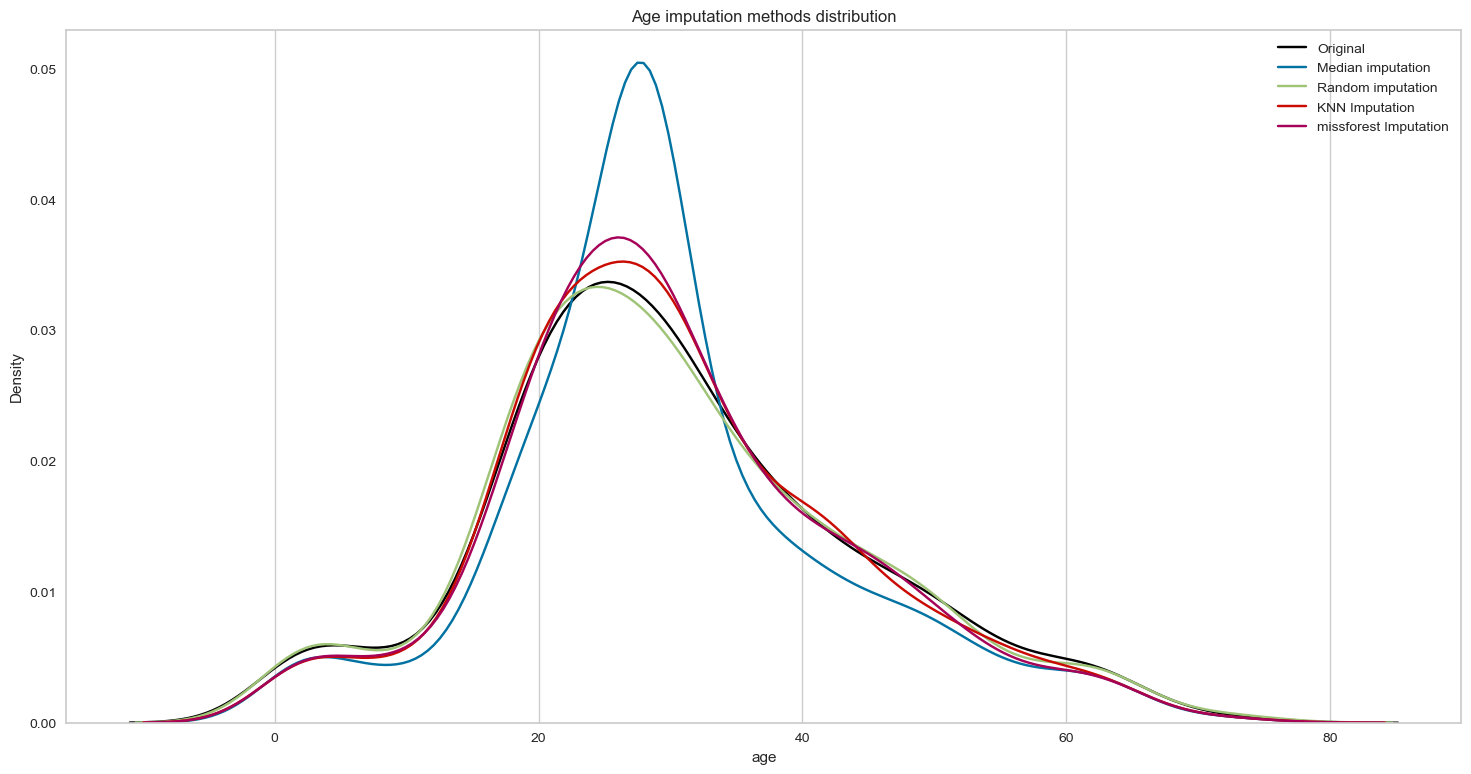

In [15]:
plt.figure(figsize = (18, 9))
sns.kdeplot(num_impute_df['age'].dropna(), label = 'Original', fill = False, color = 'black')
sns.kdeplot(num_impute_df['age_median'], label = 'Median imputation', fill = False)
sns.kdeplot(num_impute_df['age_random'], label = 'Random imputation', fill = False)
sns.kdeplot(num_impute_df['age_knn'], label = 'KNN Imputation', fill = False)
sns.kdeplot(num_impute_df['age_missforest'], label = 'missforest Imputation', fill = False)

plt.legend()

plt.grid(axis = 'y')
plt.title('Age imputation methods distribution')
plt.show


In [16]:
print('Original variance: ', num_impute_df['age'].var())
print('Variance after median imputation: ', num_impute_df['age_median'].var())
print('Variance after random sample imputation: ', num_impute_df['age_random'].var())
print('variance after knn imputation: ', num_impute_df['age_knn'].var())
print('variance after missforest imputation: ', num_impute_df['age_missforest'].var())

Original variance:  194.16304666581863
Variance after median imputation:  157.79842957602128
Variance after random sample imputation:  195.3666404357822
variance after knn imputation:  176.03428820960696
variance after missforest imputation:  173.10726956117114


For more complex models, 'KNN' and 'MissForest' are suitable, while 'Random Sample Imputation' can be used to preserve the original distribution.
The base model will be built using 'Median Imputation'.

## Encoding categorical values

In [17]:
engindata.dtypes

pclass        int64
survived      int64
sex          object
age         float64
fare        float64
embarked     object
alone         int64
dtype: object

In [18]:
engindata[features_categorical].nunique()

sex         2
embarked    3
dtype: int64

The categories have a small number of labels.
Suitable encoding methods for these categories are:</br>
    For tree-based models:</br>
        - One-Hot Encoding (not optimal for trees, but can be tested with k categories)</br>
        - Label / Ordinal / Integer Encoding</br>
        - Count or Frequency Encoding</br>
    For regression models:</br>
        -  One-Hot Encoding (use k-1 to avoid multicollinearity)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [20]:
imputer = RandomSampleImputer(random_state=0)
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test=imputer.transform(X_test)

In [21]:
X_train_OHE = get_OHE(X_train)
X_test_OHE = get_OHE(X_test)

In [22]:
X_train_OHE_DTrees = get_OHE(X_train, drop_param=False)
X_test_OHE_DTrees = get_OHE(X_test, drop_param=False)

In [23]:
X_train_ordinal = get_ordinal(X_train)
X_test_ordinal = get_ordinal(X_test)

In [24]:
X_train_count = get_count(X_train)
X_test_count = get_count(X_test)

#### FOR Regression 

In [25]:
# OHE
run_logistic(X_train_OHE,X_test_OHE, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8293264029707305

Test set
Logistic regression roc_auc: 0.8423621481112771


In [26]:
# Count Encoder
run_logistic(X_train_count,X_test_count, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8281439475895521

Test set
Logistic regression roc_auc: 0.8414495879652674


In [27]:
# Ordinal Encoder
run_logistic(X_train_ordinal,X_test_ordinal, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8265337955811392

Test set
Logistic regression roc_auc: 0.8415602013162988


####
#### For RandomForest

In [28]:
# OHE
run_randomForests(X_train_OHE_DTrees,X_test_OHE_DTrees, y_train,y_test)

Train set
Random forests roc_auc: 0.8549152405919321

Test set
Random forests roc_auc: 0.8452104419003372


In [29]:
# Count Encoder
run_randomForests(X_train_ordinal,X_test_ordinal, y_train,y_test)

Train set
Random forests roc_auc: 0.8513401999607525

Test set
Random forests roc_auc: 0.8504092693988163


In [30]:
# Ordinal Encoder
run_randomForests(X_train_count,X_test_count, y_train,y_test)

Train set
Random forests roc_auc: 0.8514559296363573

Test set
Random forests roc_auc: 0.8470770421989935


######
We can observe that One-Hot Encoding does not perform well with tree-based models but works well for regression models.
However, the other encoding methods tend to perform poorly with regression.

## Transformation and discritization

### Transfomation 

In [31]:
TransforData = engindata.copy()

In [32]:
imputer = RandomSampleImputer(random_state=0)
imputer.fit(TransforData)
TransforData = imputer.transform(TransforData)

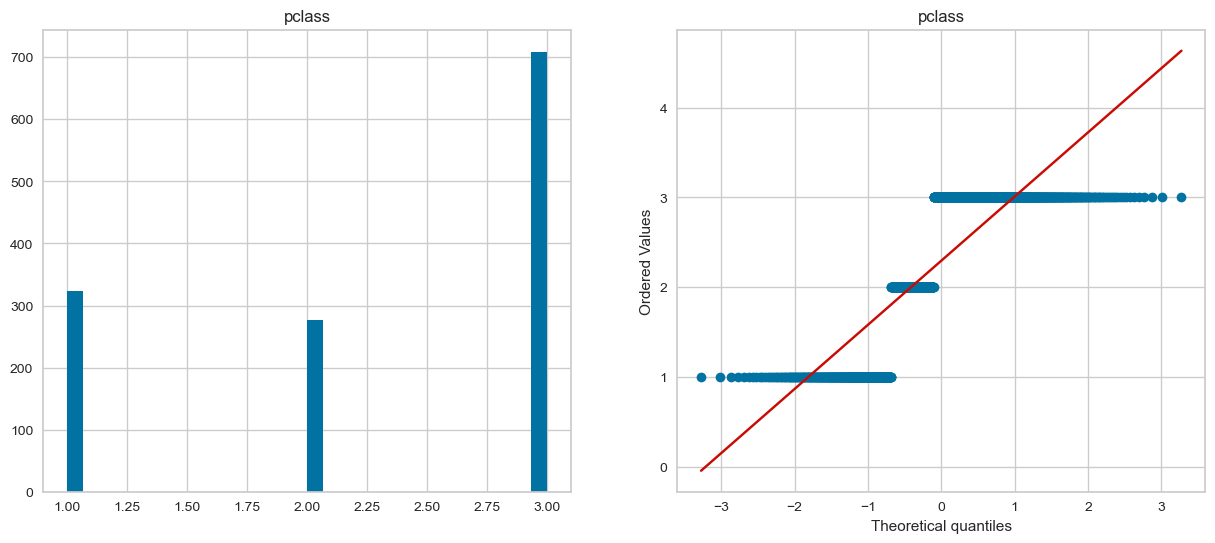

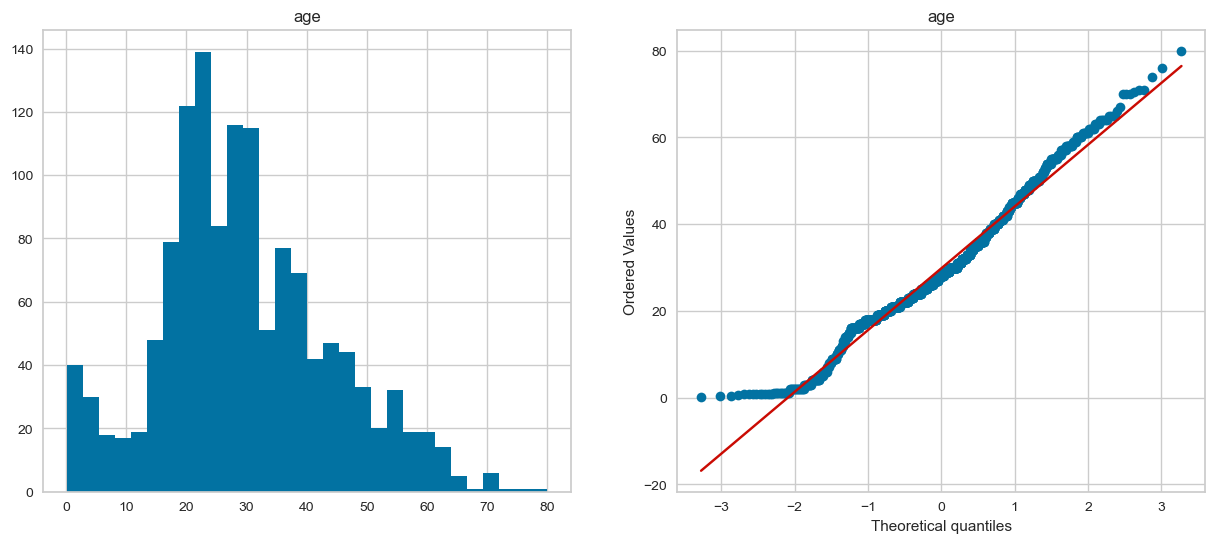

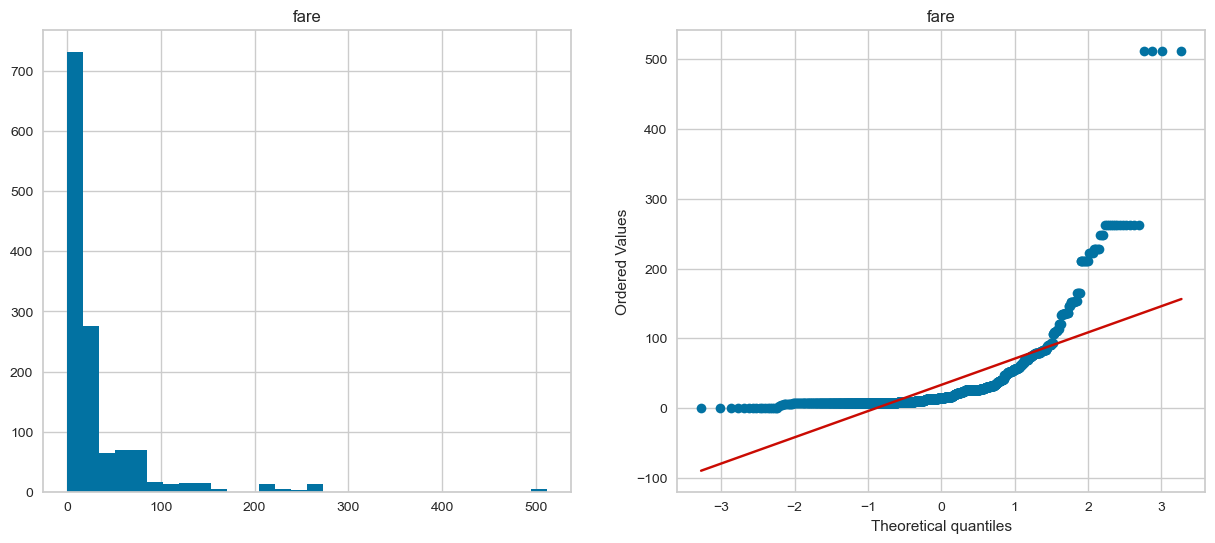

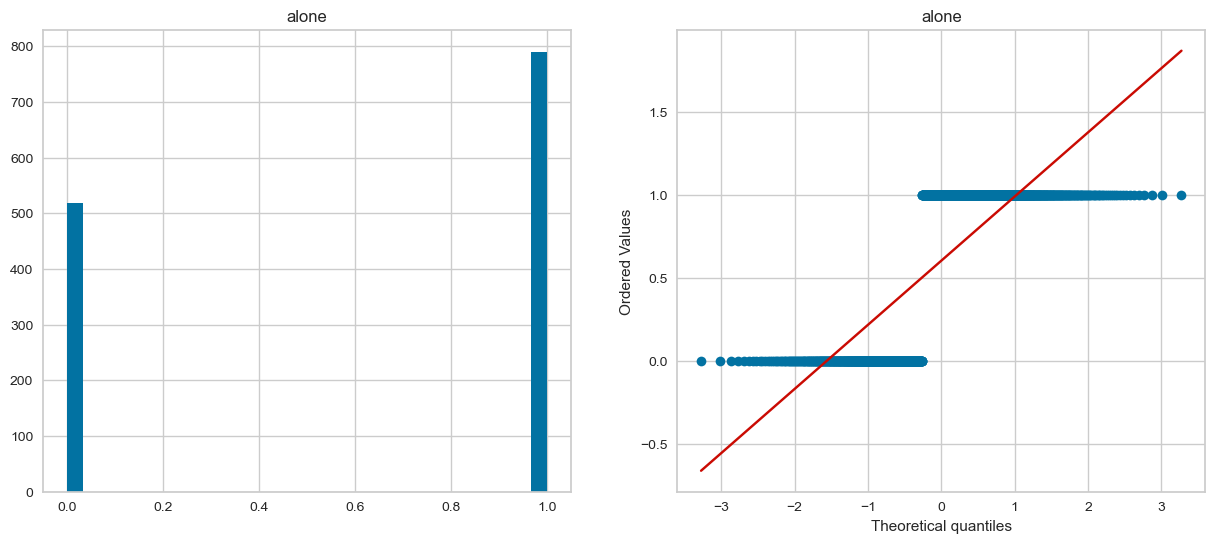

In [33]:
for var in features_numerical:
    diagnostic_plots(TransforData, var)

The variables are binary or contain a small number of labels. The remaining variables — "fare" and "age" — are skewed, so they should be transformed.
However, since these variables include zero values, transformations like LogTransformer, Box-Cox, or Reciprocal will not work.

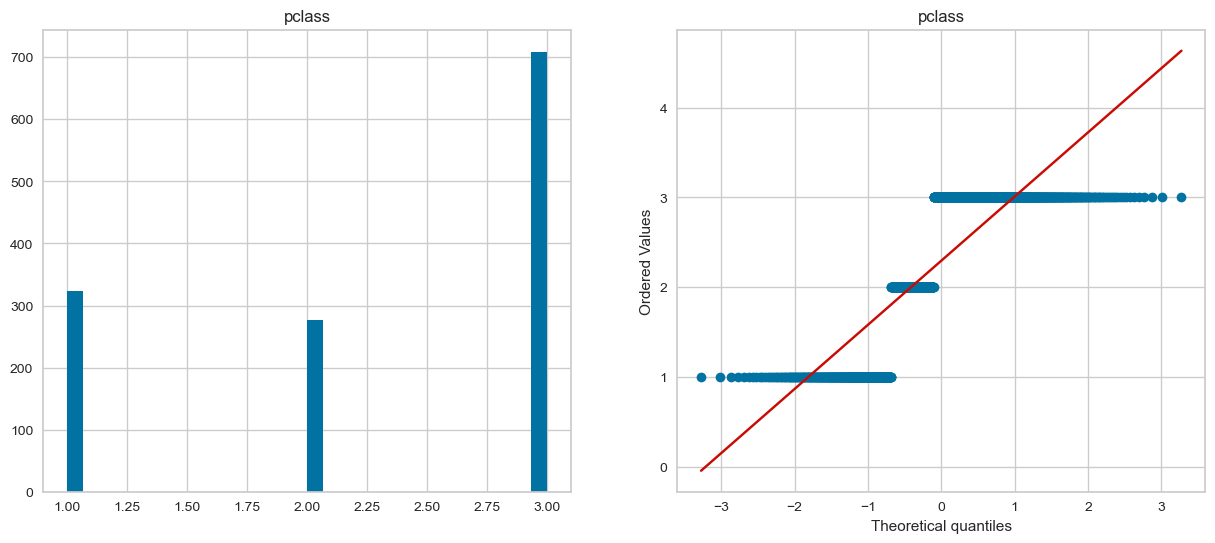

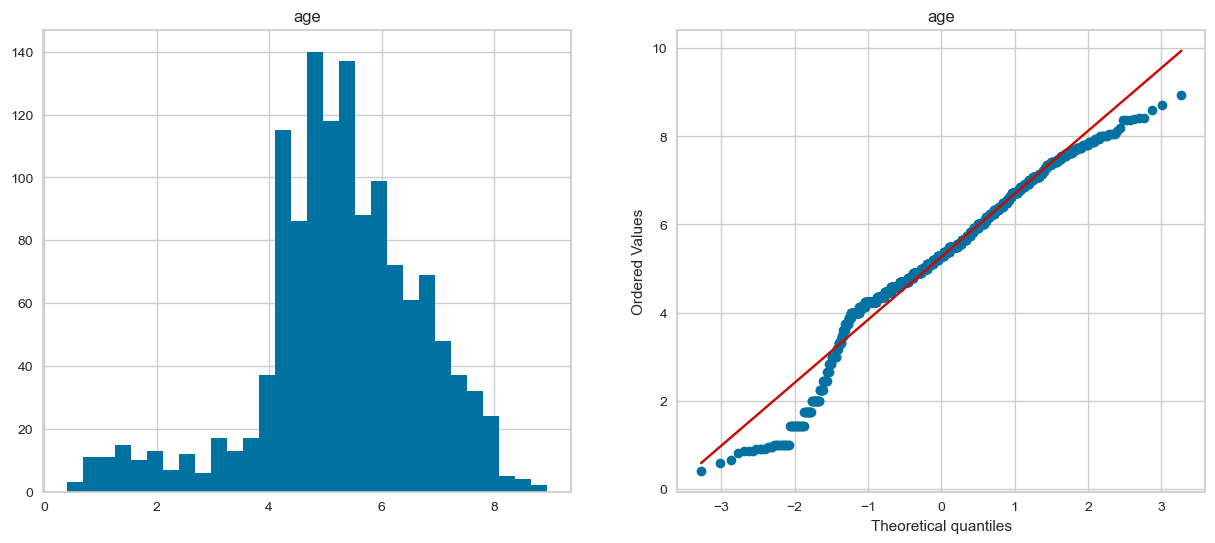

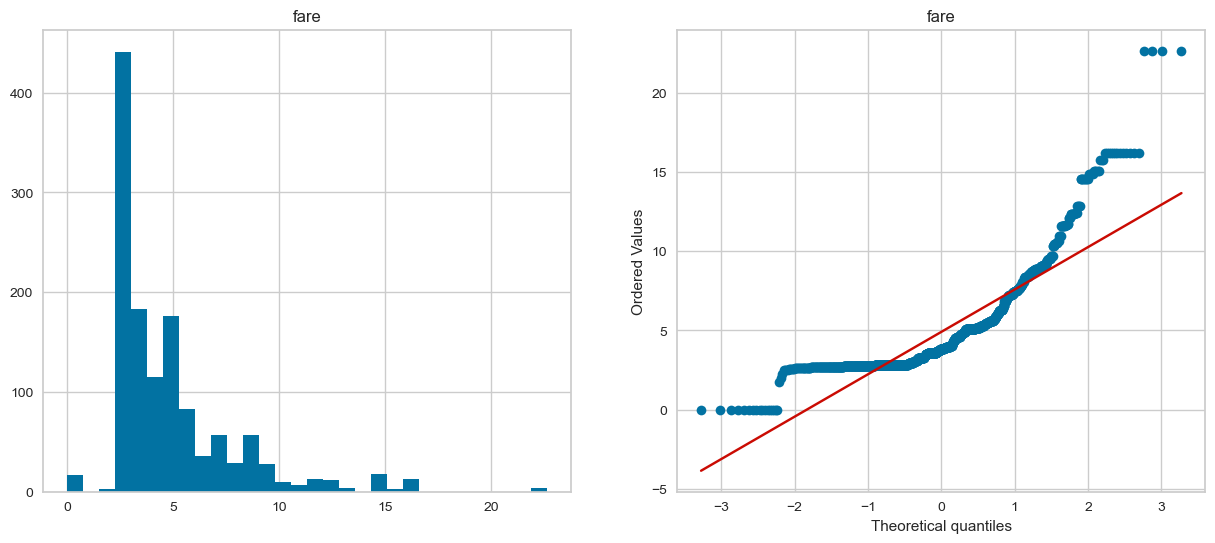

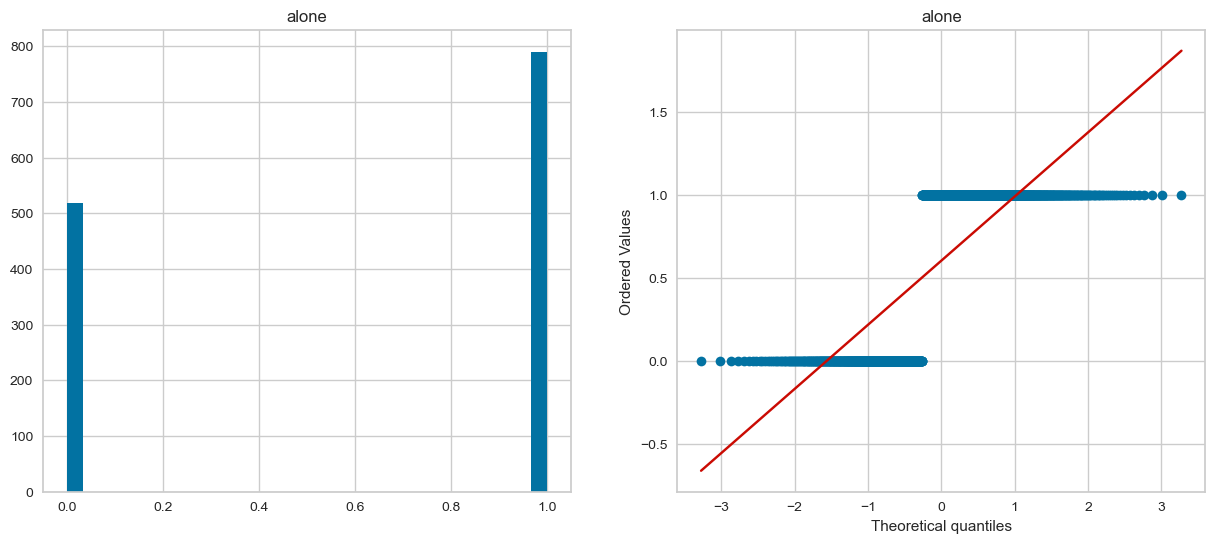

In [34]:
## Exponential
et = vt.PowerTransformer(variables=['fare', 'age'])
et.fit(TransforData)
data_ef = et.transform(TransforData)
data_ef_numerical = [c for c in data_ef.columns if data_ef[c].dtypes !='O' and c!='survived']
for var in data_ef_numerical:
    diagnostic_plots(data_ef, var)

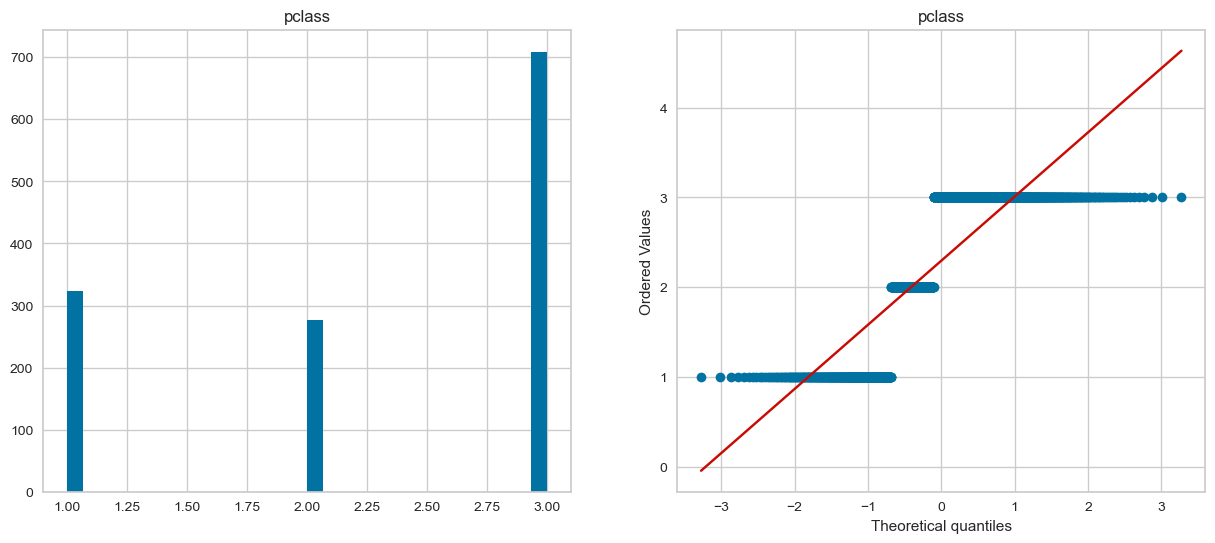

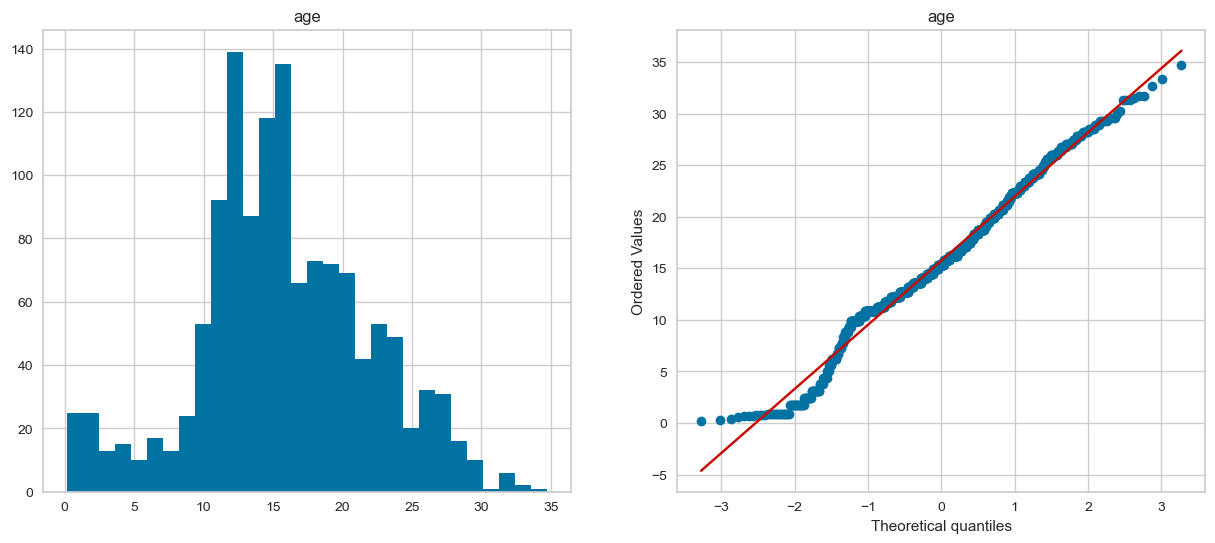

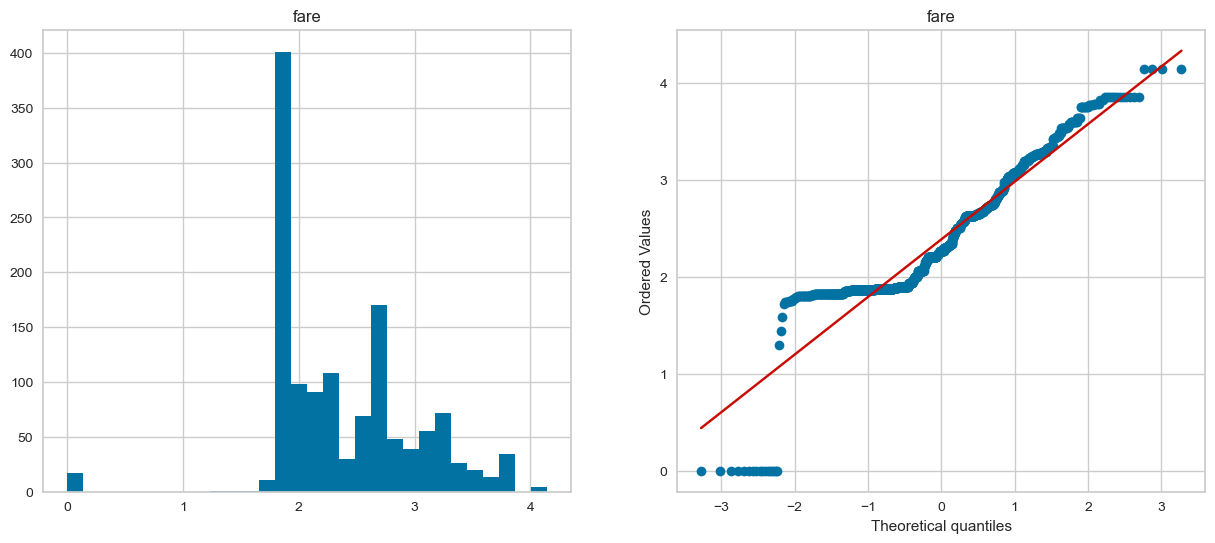

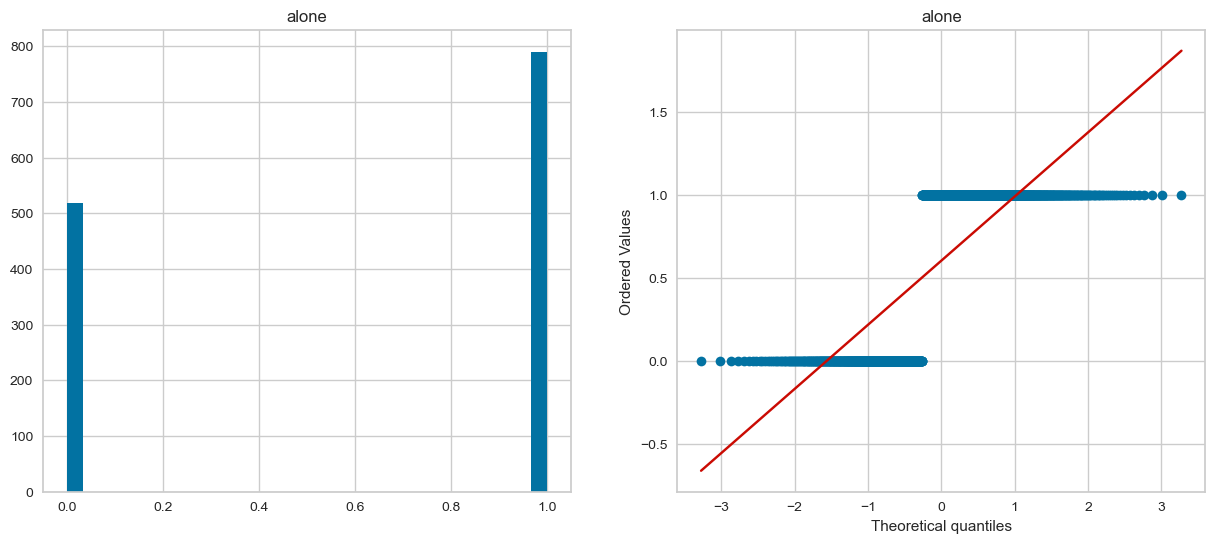

In [35]:
## Yeo-Jojhson
yjt = vt.YeoJohnsonTransformer(variables=['fare', 'age'])
yjt.fit(TransforData)
data_yjt = yjt.transform(TransforData)
data_yjt_numerical = [c for c in data_yjt.columns if data_yjt[c].dtypes !='O' and c!='survived']
for var in data_yjt_numerical:
    diagnostic_plots(data_yjt, var)

A clear improvement in the distribution can be observed after applying the Yeo-Johnson transformation

## Magnitude

In [36]:
ScalerData = engindata.copy()
imputer = RandomSampleImputer(random_state=0)
imputer.fit(ScalerData)
ScalerData= imputer.transform(ScalerData)

In [37]:
OHE = OneHotEncoder(drop_last=True)
ScalerData = OHE.fit_transform(ScalerData)

In [38]:
# RobustScaler
scaler = RobustScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

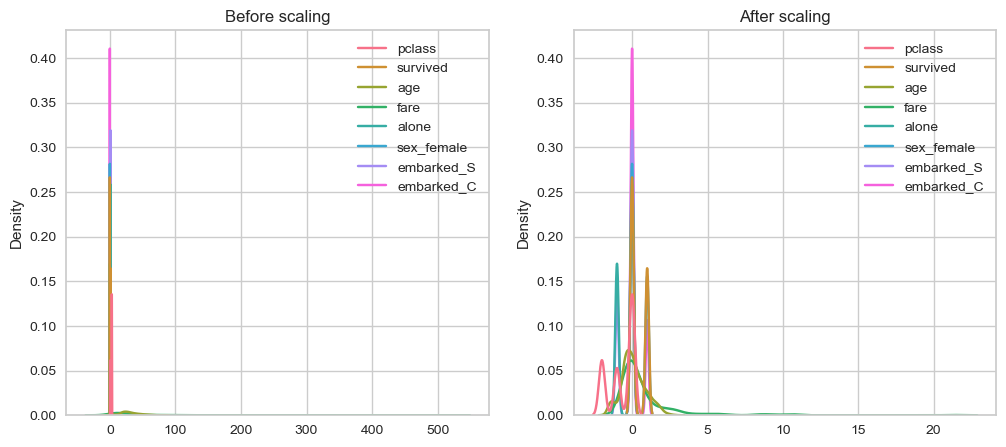

In [39]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

In [40]:
# StandardScaler
scaler = StandardScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

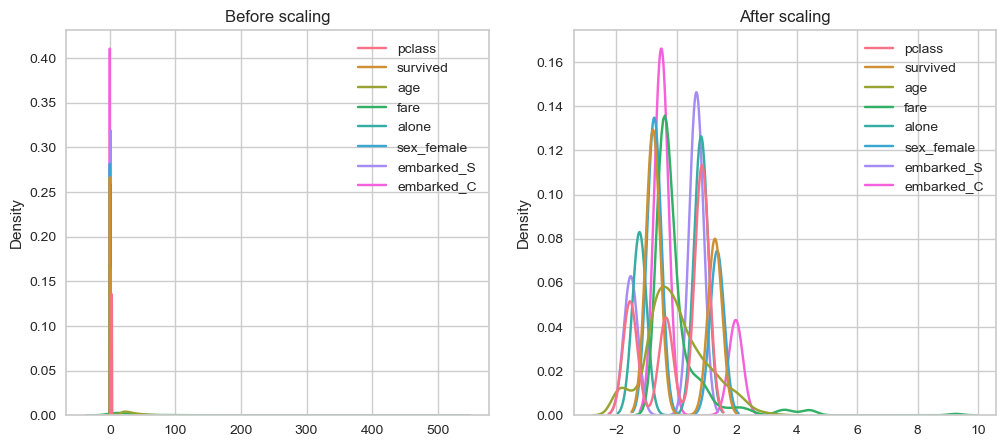

In [41]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

In [42]:
# MinMaxScaler
scaler = MinMaxScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

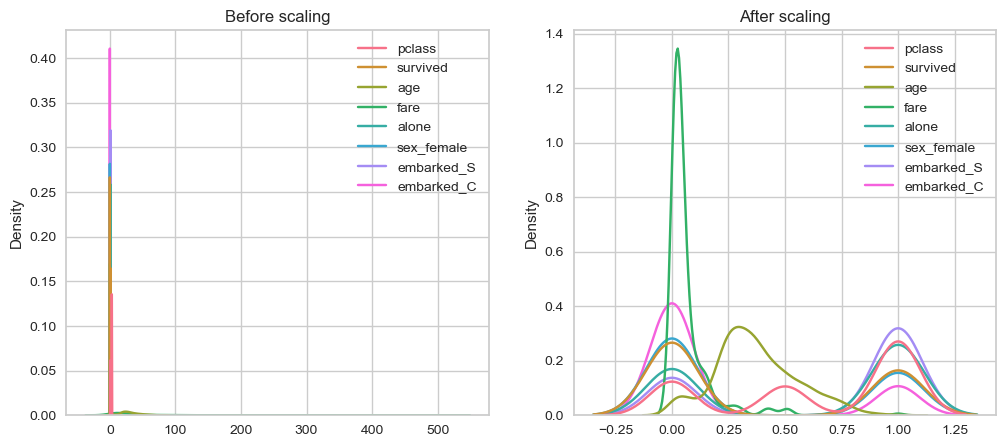

In [43]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

The graphs show that the data scales well using both MinMaxScaling and StandardScaling

## Baseline model

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [45]:
# zero hypotheses
y_pred_base = np.zeros((len(y_test)))
compare = y_pred_base == y_test
acc_base = sum(compare) / len(compare)
print('Base Line Test Accuracy = ', acc_base)

Base Line Test Accuracy =  0.6259541984732825


In [46]:
baseline = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='median')),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [47]:
baseline.fit(X_train, y_train)

Pipeline(steps=[('imputer', MeanMedianImputer()),
                ('cat_encoder', OneHotEncoder(drop_last=True)),
                ('scaler', StandardScaler()),
                ('Logit', LogisticRegression(random_state=0))])

In [48]:
X_train_proba = baseline.predict_proba(X_train)
X_test_proba = baseline.predict_proba(X_test)

In [49]:
print('Train Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_train, X_train_proba[:, 1])))

Train Set
Logistic regression roc-auc:0.8359934386305656


In [50]:
print('Test Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))


Test Set
Logistic regression roc-auc:0.8413804546208727


In [51]:
X_train_pred = baseline.predict(X_train)
X_test_pred = baseline.predict(X_test)

In [52]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       563
           1       0.72      0.71      0.72       353

    accuracy                           0.78       916
   macro avg       0.77      0.77      0.77       916
weighted avg       0.78      0.78      0.78       916



In [53]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       246
           1       0.75      0.68      0.71       147

    accuracy                           0.79       393
   macro avg       0.78      0.77      0.78       393
weighted avg       0.79      0.79      0.79       393



In [72]:
results = pd.DataFrame(columns=['F1', 'Accuracy', 'ROC AUC']).T

In [73]:
results = metrics_gridsearch ("logistic_regression", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1], results)

## Grid Search for LogisticRegression

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [132]:
Logit_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    ('discretizer', EqualFrequencyDiscretiser(q=6, variables=['fare', 'age'])),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0, C=1, max_iter=100))
])

In [133]:
Logit_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    'discretizer':  [EqualFrequencyDiscretiser()],
    'discretizer':  [DecisionTreeDiscretiser(cv = 10, scoring='accuracy', variables=['fare','age'], regression=False, param_grid={'max_depth': [1,2,3], 'min_samples_leaf': [10,4]})],
    'scaler': [StandardScaler(), MinMaxScaler()],
    'Logit__C': [1,2],
    'Logit__max_iter': [50, 100]
}
    

In [134]:
Logit_grid_search = GridSearchCV(estimator=Logit_Pipe, param_grid=Logit_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [135]:
LOGIT_MODEL = Logit_grid_search.fit(X_train, y_train)

In [136]:
LOGIT_MODEL.best_params_

{'Logit__C': 1,
 'Logit__max_iter': 50,
 'cat_encoder': OrdinalEncoder(),
 'discretizer': DecisionTreeDiscretiser(cv=10,
                         param_grid={'max_depth': [1, 2, 3],
                                     'min_samples_leaf': [10, 4]},
                         regression=False, scoring='accuracy',
                         variables=['fare', 'age']),
 'imputer_age': SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                        initial_strategy='median',
                                                        random_state=0,
                                                        skip_complete=True)),
 'scaler': MinMaxScaler()}

In [137]:
LOGIT_MODEL.cv_results_

{'mean_fit_time': array([0.38712564, 0.37300386, 0.5449367 , 0.59144273, 0.38805451,
        0.43582172, 0.38887062, 0.39120135, 0.3775991 , 0.40328493,
        0.57353449, 0.56951804, 0.39058247, 0.38599195, 0.41820269,
        0.38488588, 0.3663888 , 0.37579226, 0.5863358 , 0.57022758,
        0.37648048, 0.37188311, 0.39819217, 0.38488359, 0.40528307,
        0.36306996, 0.58772912, 0.54786406, 0.38513103, 0.40733981,
        0.40444479, 0.39403963, 0.38683367, 0.38327794, 0.56892376,
        0.58152909, 0.37457819, 0.40268898, 0.39158196, 0.39248743,
        0.41948628, 0.38848701, 0.63044858, 0.60814314, 0.39249444,
        0.3966023 , 0.43182859, 0.40628848, 0.38567624, 0.39037886,
        0.55902414, 0.57684598, 0.37389793, 0.40341339, 0.40352144,
        0.38529577, 0.37179704, 0.37288241, 0.57453866, 0.57283559,
        0.38208871, 0.36969485, 0.41410308, 0.37310333, 0.38720331,
        0.3836906 , 0.54983106, 0.57923331, 0.36589661, 0.36729064,
        0.41249418, 0.3805872 ,

In [138]:
X_train_proba = LOGIT_MODEL.predict_proba(X_train)
X_test_proba = LOGIT_MODEL.predict_proba(X_test)

In [139]:
print('Train Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_train, X_train_proba[:, 1])))

Train Set
Logistic regression roc-auc:0.8455386210054393


In [140]:
print('Test Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))


Test Set
Logistic regression roc-auc:0.8518748962999834


In [141]:
X_train_pred = LOGIT_MODEL.predict(X_train)
X_test_pred = LOGIT_MODEL.predict(X_test)

In [142]:
Logit_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                        initial_strategy='median',
                                                                        random_state=0,
                                                                        skip_complete=True))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('discretizer',
                 DecisionTreeDiscretiser(cv=10,
                                         param_grid={'max_depth': [1, 2, 3],
                                                     'min_samples_leaf': [10,
                                                                          4]},
                                         regression=False, scoring='accuracy',
                                         variables=['fare', 'age'])),
                ('scaler', MinMaxScaler()),
                ('Logit',
                 LogisticRegression(C=1, max_iter=50, random_state=0))])

In [143]:
print(classification_report(y_train,X_train_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       563
           1       0.75      0.70      0.72       353

    accuracy                           0.79       916
   macro avg       0.78      0.78      0.78       916
weighted avg       0.79      0.79      0.79       916



In [144]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       246
           1       0.72      0.66      0.69       147

    accuracy                           0.78       393
   macro avg       0.76      0.75      0.76       393
weighted avg       0.77      0.78      0.77       393



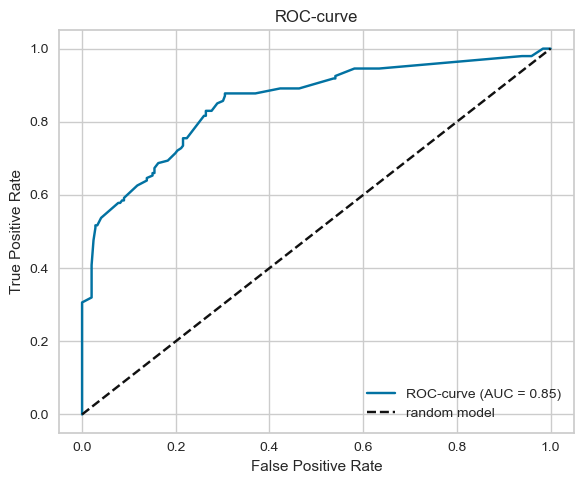

In [145]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:, 1])
auc = roc_auc_score(y_test, X_test_proba[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

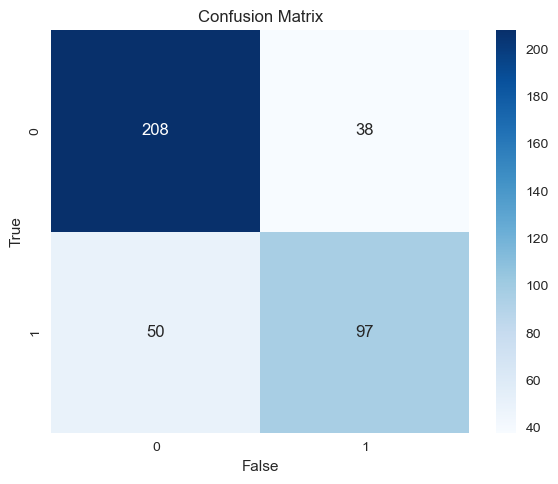

In [146]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False,)

In [147]:
results = metrics_gridsearch ("logistic_regressionGS", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1], results)

"Performs worse, underfitting is present. The model makes more errors.

## GridSearch for SVC

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [188]:
SVM_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    #('discretizer', EqualFrequencyDiscretiser(q=6, variables=['fare', 'age'])),
    ('scaler', StandardScaler()),
    ('SVM', SVC(kernel='rbf', random_state=0, C=1, max_iter=100))
])

In [189]:
SVM_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualFrequencyDiscretiser(q=6, variables=['fare', 'age']), 
    #                DecisionTreeDiscretiser(cv = 10, scoring='accuracy', variables=['fare', 'age'], regression=False, param_grid={'max_depth': [1,2,3], 'min_samples_leaf': [10,4]})],
    'scaler': [StandardScaler(), RobustScaler()],
    'SVM__kernel': ['rbf', 'linear','poly'],
    'SVM__C': [0.1, 1, 10 ],
    'SVM__max_iter': [50, 100, 150]}
    

In [190]:
SVC_grid_search = GridSearchCV(estimator=SVM_Pipe, param_grid=SVM_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [191]:
SVC_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=150).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder',
                                        OneHotEncoder(drop_last=True)),
                                       ('scaler', StandardScaler()),
                                       ('SVM',
                                        SVC(C=1, max_iter=100,
                                            random_state=0))]),
             n_jobs=-1,
             param_grid={'SVM__C': [0.1, 1, 10],
                         'SVM__ke...
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))],
                         'scaler': [StandardScaler(), RobustScaler()]},
             scoring='roc_auc')

In [192]:
SVC_grid_search.best_params_

{'SVM__C': 0.1,
 'SVM__kernel': 'rbf',
 'SVM__max_iter': 150,
 'cat_encoder': OneHotEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                  weights='distance')),
 'scaler': RobustScaler()}

In [193]:
SVC_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                  weights='distance'))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OneHotEncoder()), ('scaler', RobustScaler()),
                ('SVM', SVC(C=0.1, max_iter=150, random_state=0))])

In [194]:
X_train_proba = SVC_grid_search.decision_function(X_train)
X_test_proba = SVC_grid_search.decision_function(X_test)

In [195]:
print("Best SVM model from grid search: {:.3f}".format(SVC_grid_search.score(X_train,y_train)))
print("Best SVM model from grid search: {:.3f}".format(SVC_grid_search.score(X_test,y_test)))

Best SVM model from grid search: 0.803
Best SVM model from grid search: 0.807


In [196]:
X_train_pred = SVC_grid_search.predict(X_train)
X_test_pred = SVC_grid_search.predict(X_test)

In [197]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.85      0.62      0.72       563
           1       0.58      0.83      0.68       353

    accuracy                           0.70       916
   macro avg       0.71      0.72      0.70       916
weighted avg       0.74      0.70      0.70       916



In [198]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.63      0.72       246
           1       0.56      0.81      0.66       147

    accuracy                           0.69       393
   macro avg       0.71      0.72      0.69       393
weighted avg       0.74      0.69      0.70       393



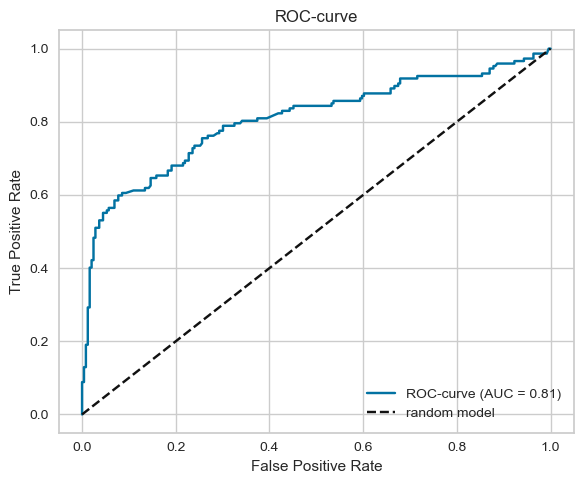

In [199]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba)
auc = roc_auc_score(y_test, X_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

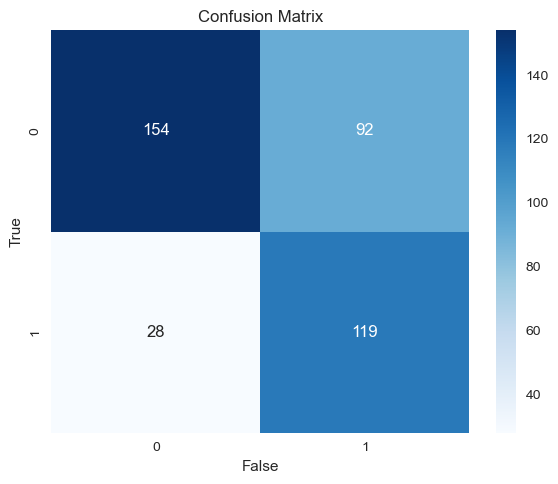

In [200]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [201]:
results = metrics_gridsearch ("SVC", y_test, y_train, X_test_pred, X_test_proba, X_train_pred, X_train_proba, results)

This model shows the worst performance across all metrics; therefore, it will be excluded.

## GridSearch for K-nn

In [202]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [219]:
KNN_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    ('discretizer', EqualWidthDiscretiser(bins=8, variables=['fare','age'])),
    ('scaler', StandardScaler()),
    ('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2))
])

In [220]:
KNN_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
                    KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='kmeans')],
    'scaler': [StandardScaler(), RobustScaler()],
    'KNN__n_neighbors': [10,15,20],
    'KNN__p': [1,2]}
    

In [221]:
KNN_grid_search = GridSearchCV(estimator=KNN_Pipe, param_grid=KNN_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [222]:
KNN_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder',
                                        OneHotEncoder(drop_last=True)),
                                       ('discretizer',
                                        EqualWidthDiscretiser(bins=8,
                                                              variables=['fare',
                                                                         'age'])),
                                       ('scaler', StandardScaler()),
                                       ('KNN', KNeighborsClassifie...
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))],
                         'scaler': [StandardScaler(), RobustScaler()]},
             scoring='roc_auc')

In [223]:
KNN_grid_search.best_params_

{'KNN__n_neighbors': 15,
 'KNN__p': 2,
 'cat_encoder': OneHotEncoder(),
 'imputer_age': RandomSampleImputer(random_state=0),
 'scaler': StandardScaler()}

In [224]:
KNN_grid_search.best_estimator_

Pipeline(steps=[('imputer_age', RandomSampleImputer(random_state=0)),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OneHotEncoder()),
                ('discretizer',
                 EqualWidthDiscretiser(bins=8, variables=['fare', 'age'])),
                ('scaler', StandardScaler()),
                ('KNN', KNeighborsClassifier(n_neighbors=15))])

In [225]:
X_train_proba = KNN_grid_search.predict_proba(X_train)
X_test_proba = KNN_grid_search.predict_proba(X_test)

In [226]:
print("Best KNN model from grid search: {:.3f}".format(KNN_grid_search.score(X_train,y_train)))
print("Best KNN model from grid search: {:.3f}".format(KNN_grid_search.score(X_test,y_test)))

Best KNN model from grid search: 0.880
Best KNN model from grid search: 0.832


In [288]:
X_train_pred = KNN_grid_search.predict(X_train)
X_test_pred = KNN_grid_search.predict(X_test)

In [289]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       563
           1       0.79      0.71      0.75       353

    accuracy                           0.82       916
   macro avg       0.81      0.80      0.80       916
weighted avg       0.82      0.82      0.81       916



In [290]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       246
           1       0.77      0.65      0.70       147

    accuracy                           0.79       393
   macro avg       0.79      0.76      0.77       393
weighted avg       0.79      0.79      0.79       393



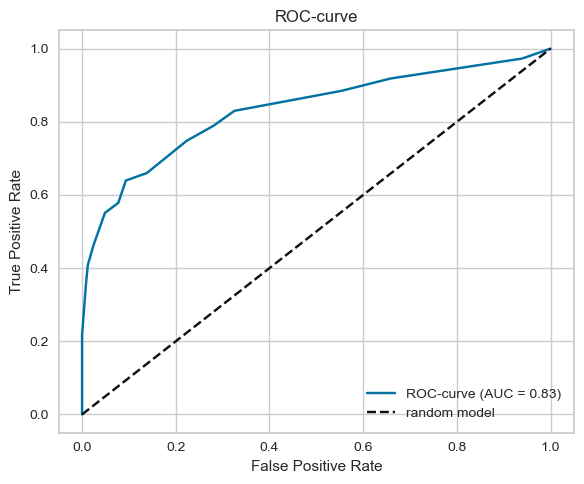

In [227]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

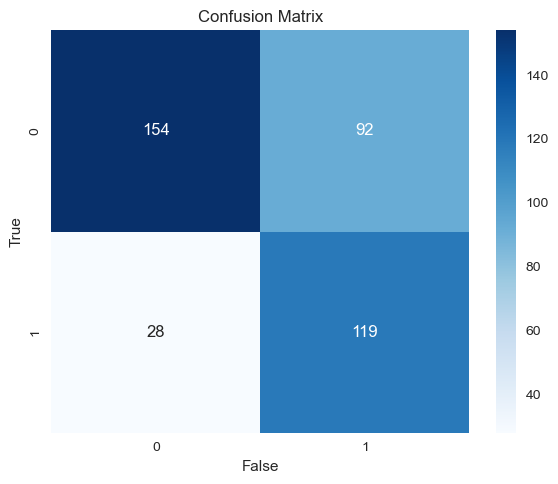

In [228]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [229]:
results = metrics_gridsearch ("KNN", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [230]:
results

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train
F1,0.7117,0.7153,0.6879,0.7225,0.6648,0.6791,0.6648,0.6791
Accuracy,0.7939,0.7828,0.7761,0.7937,0.6947,0.6987,0.6947,0.6987
ROC AUC,0.8414,0.8360,0.8519,0.8455,0.8068,0.8034,0.8324,0.8799


## RandomForest

In [231]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [255]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    ('discretizer', EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
    ('Tree', RandomForestClassifier(n_estimators=100,min_samples_split=10, min_samples_leaf=5, random_state=0, class_weight='balanced'))
])

In [256]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    'discretizer': [EqualWidthDiscretiser(bins=5, variables=['age', 'fare']), 
                   KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__n_estimators': [50,100,150],
    'Tree__min_samples_leaf': [1,3],
    'Tree__max_depth': [1,2,3],
    'Tree__min_samples_split': [2,3],
    'Tree__max_features': ['sqrt', 'log2', 0.3, 0.5]}
    

In [257]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [258]:
Tree_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('discretizer',
                                        EqualWidthDiscretiser(bins=8,
                                                              variables=['age',
                                                                         'fare'])),
                                       ('Tree',
                                        RandomForestClassifier(class_weight='balanced',
                                                               min_samples_...
                                                          strategy='kmeans')],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [259]:
Tree_grid_search.best_params_

{'Tree__max_depth': 3,
 'Tree__max_features': 0.5,
 'Tree__min_samples_leaf': 1,
 'Tree__min_samples_split': 2,
 'Tree__n_estimators': 50,
 'cat_encoder': OrdinalEncoder(),
 'discretizer': EqualWidthDiscretiser(bins=5, variables=['age', 'fare']),
 'imputer_age': RandomSampleImputer(random_state=0)}

In [260]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age', RandomSampleImputer(random_state=0)),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('discretizer',
                 EqualWidthDiscretiser(bins=5, variables=['age', 'fare'])),
                ('Tree',
                 RandomForestClassifier(class_weight='balanced', max_depth=3,
                                        max_features=0.5, n_estimators=50,
                                        random_state=0))])

In [261]:
X_train_proba = Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [262]:
print('Train Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
RandomForest roc-auc:0.8497275320898265
Test Set
RandomForest roc-auc:0.8508102427963056


In [263]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [264]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       563
           1       0.78      0.71      0.74       353

    accuracy                           0.81       916
   macro avg       0.80      0.79      0.80       916
weighted avg       0.81      0.81      0.81       916



In [265]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       246
           1       0.78      0.66      0.72       147

    accuracy                           0.80       393
   macro avg       0.80      0.78      0.78       393
weighted avg       0.80      0.80      0.80       393



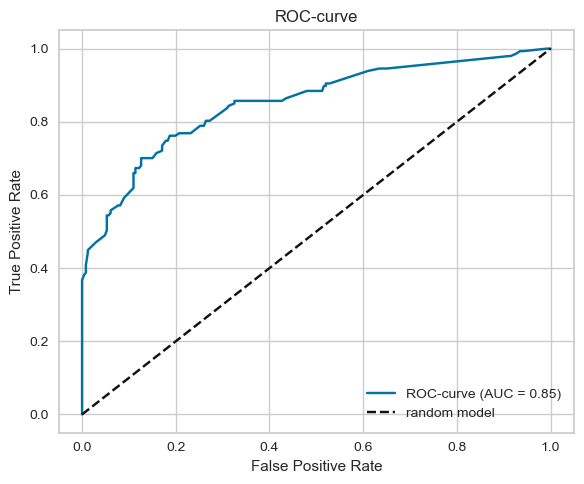

In [266]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

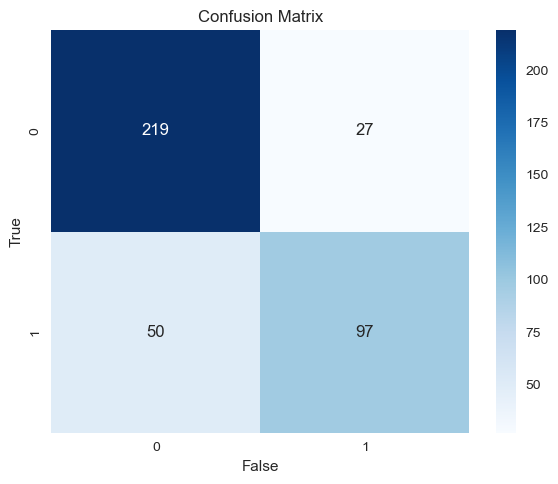

In [267]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [268]:
results = metrics_gridsearch ("RandomForest", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

####  Based on the obtained results, we can confidently state that tree-based models perform significantly better.

### GBM

In [290]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [311]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    #('discretizer', EqualWidthDiscretiser(bins=5, variables=['fare','age'])),
    ('Tree', GradientBoostingClassifier( max_depth=2, random_state=0))
])

In [312]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
    #               KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__n_estimators': [30],
    'Tree__min_samples_leaf': [3, 5],
    'Tree__min_samples_split': [3, 5]}
    

In [313]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [314]:
Tree_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('Tree',
                                        GradientBoostingClassifier(max_depth=2,
                                                                   random_state=0))]),
             n_jobs=-1,
             param_grid={'Tree__min_samples_leaf': [3, 5],
                         'Tree__min_samples_...
                                         CountFrequencyEncoder()],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [315]:
Tree_grid_search.best_params_

{'Tree__min_samples_leaf': 5,
 'Tree__min_samples_split': 3,
 'Tree__n_estimators': 30,
 'cat_encoder': OrdinalEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                        initial_strategy='median',
                                                        random_state=0,
                                                        skip_complete=True))}

In [316]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                        initial_strategy='median',
                                                                        random_state=0,
                                                                        skip_complete=True))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('Tree',
                 GradientBoostingClassifier(max_depth=2, min_samples_leaf=5,
                                            min_samples_split=3,
                                            n_estimators=30, random_state=0))])

In [317]:
X_train_proba= Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [318]:
print('Train Set')
print('GBM roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('GBM roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
GBM roc-auc:0.8690946417160195
Test Set
GBM roc-auc:0.859686964216581


In [319]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [320]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86       563
           1       0.86      0.61      0.71       353

    accuracy                           0.81       916
   macro avg       0.83      0.77      0.79       916
weighted avg       0.82      0.81      0.80       916



In [321]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.79      0.93      0.86       246
           1       0.84      0.58      0.69       147

    accuracy                           0.80       393
   macro avg       0.81      0.76      0.77       393
weighted avg       0.81      0.80      0.79       393



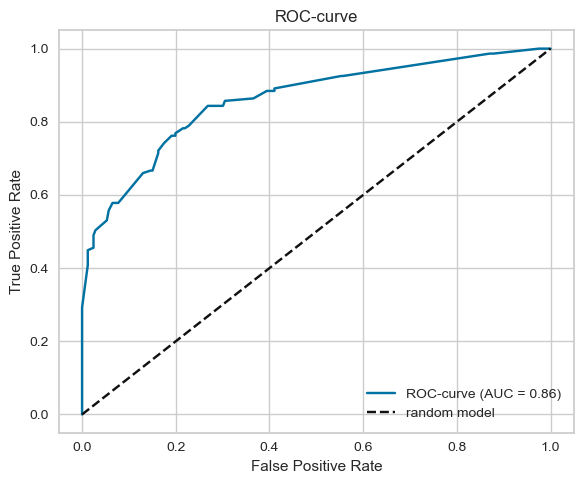

In [322]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

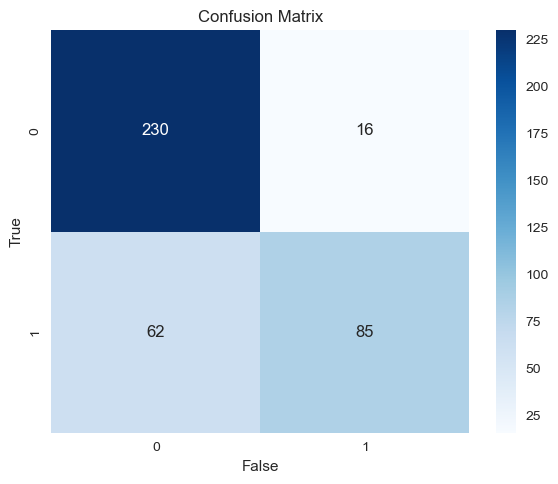

In [323]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [324]:
results = metrics_gridsearch ("GradientBoosting", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [325]:
results

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train,RandomForest_test,RandomForest_train,GradientBoosting_test,GradientBoosting_train
F1,0.7117,0.7153,0.6879,0.7225,0.6648,0.6791,0.6648,0.6791,0.7159,0.7426,0.6855,0.7143
Accuracy,0.7939,0.7828,0.7761,0.7937,0.6947,0.6987,0.6947,0.6987,0.8041,0.8100,0.8015,0.8122
ROC AUC,0.8414,0.8360,0.8519,0.8455,0.8068,0.8034,0.8324,0.8799,0.8508,0.8497,0.8597,0.8691


## Decision Tree

In [359]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 6), (393, 6))

In [360]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    ('discretizer', EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
    ('Tree', DecisionTreeClassifier(random_state=0, max_depth=4))
])

In [375]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
                   KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__min_samples_leaf': [2,3,4],
    'Tree__min_samples_split': [4,5]}
    

In [376]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [377]:
Tree_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('discretizer',
                                        EqualWidthDiscretiser(bins=8,
                                                              variables=['age',
                                                                         'fare'])),
                                       ('Tree',
                                        DecisionTreeClassifier(max_depth=4,
                                                               random_state=0))]),
             n_job...
                                                          strategy='kmeans')],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [378]:
Tree_grid_search.best_params_

{'Tree__min_samples_leaf': 3,
 'Tree__min_samples_split': 4,
 'cat_encoder': CountFrequencyEncoder(),
 'discretizer': EqualWidthDiscretiser(bins=8, variables=['age', 'fare']),
 'imputer_age': SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                        initial_strategy='median',
                                                        random_state=0,
                                                        skip_complete=True))}

In [379]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                        initial_strategy='median',
                                                                        random_state=0,
                                                                        skip_complete=True))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', CountFrequencyEncoder()),
                ('discretizer',
                 EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
                ('Tree',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=3,
                                        min_samples_split=4, random_state=0))])

In [380]:
X_train_proba = Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [381]:
print('Train Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
RandomForest roc-auc:0.8669712537549249
Test Set
RandomForest roc-auc:0.8462197887284996


In [382]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [383]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       563
           1       0.85      0.64      0.73       353

    accuracy                           0.82       916
   macro avg       0.83      0.78      0.79       916
weighted avg       0.82      0.82      0.81       916



In [384]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.93      0.86       246
           1       0.84      0.63      0.72       147

    accuracy                           0.81       393
   macro avg       0.82      0.78      0.79       393
weighted avg       0.82      0.81      0.81       393



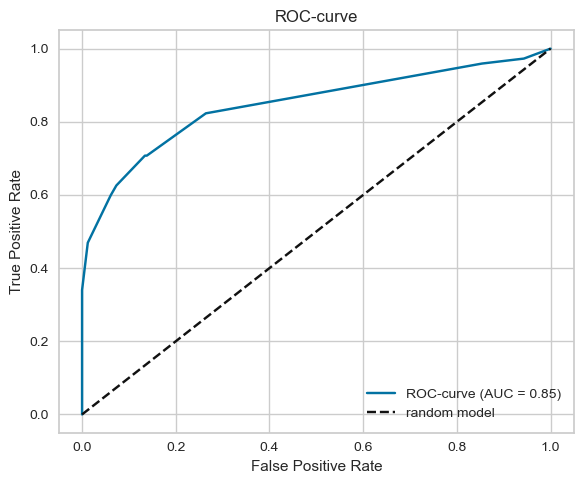

In [385]:
fpr, tpr, thresholds = roc_curve(y_test,  X_test_proba[:,1])
auc = roc_auc_score(y_test,  X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

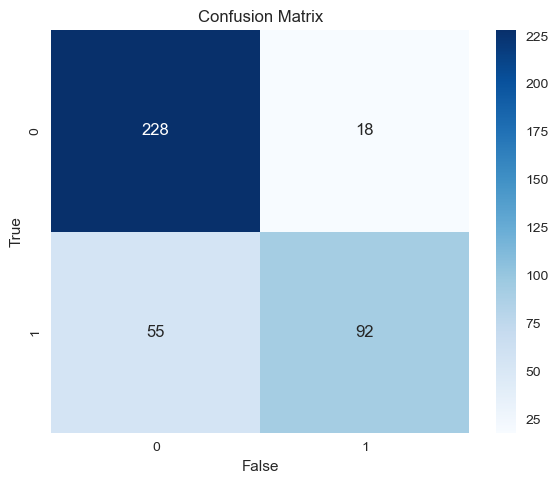

In [386]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [387]:
results = metrics_gridsearch ("DecisionTree", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [388]:
results

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train,RandomForest_test,RandomForest_train,GradientBoosting_test,GradientBoosting_train,DecisionTree_test,DecisionTree_train
F1,0.7117,0.7153,0.6879,0.7225,0.6648,0.6791,0.6648,0.6791,0.7159,0.7426,0.6855,0.7143,0.7160,0.7282
Accuracy,0.7939,0.7828,0.7761,0.7937,0.6947,0.6987,0.6947,0.6987,0.8041,0.8100,0.8015,0.8122,0.8142,0.8166
ROC AUC,0.8414,0.8360,0.8519,0.8455,0.8068,0.8034,0.8324,0.8799,0.8508,0.8497,0.8597,0.8691,0.8462,0.8670


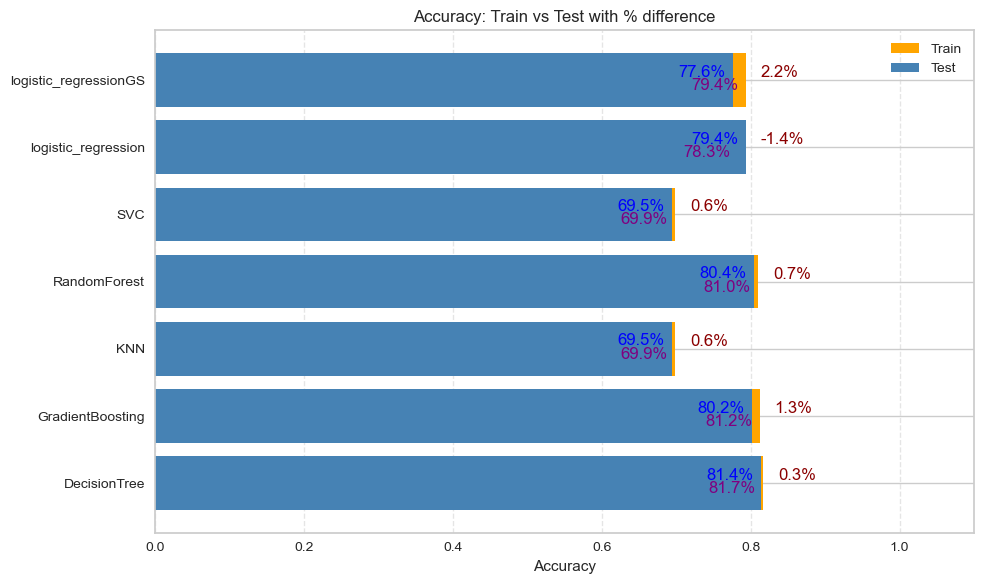

In [389]:
plot_overfit_with_exact_labels(results, 'Accuracy')

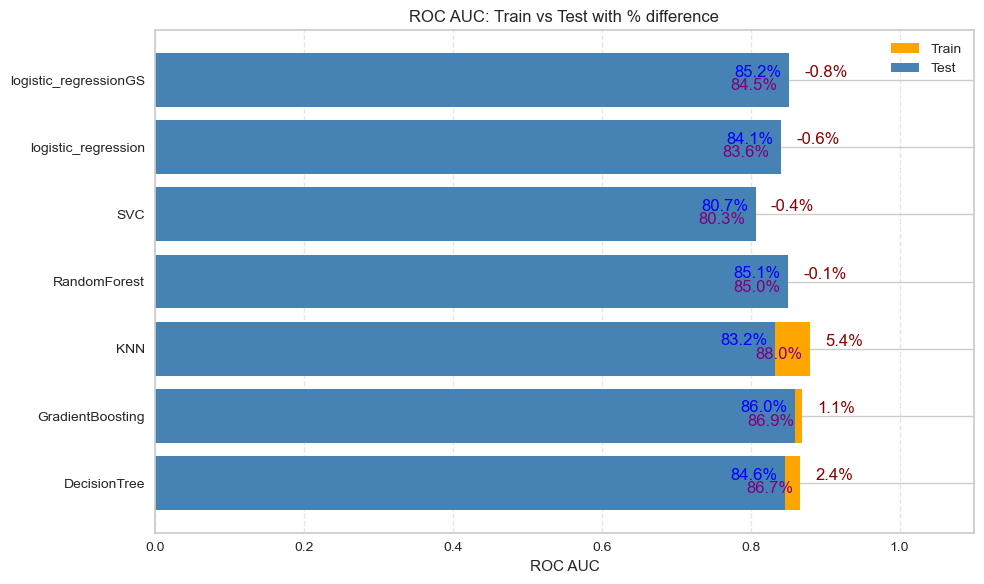

In [390]:
plot_overfit_with_exact_labels(results, 'ROC AUC')

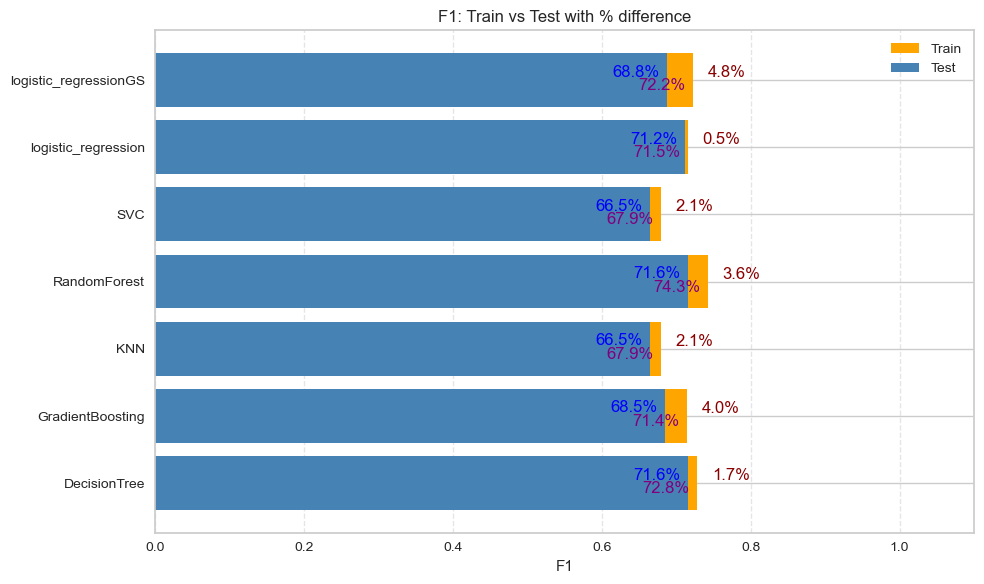

In [391]:
plot_overfit_with_exact_labels(results, 'F1')